/tmp/ipykernel_1928565/2787044492.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Plot successfully saved to sensitivity_comparison.png


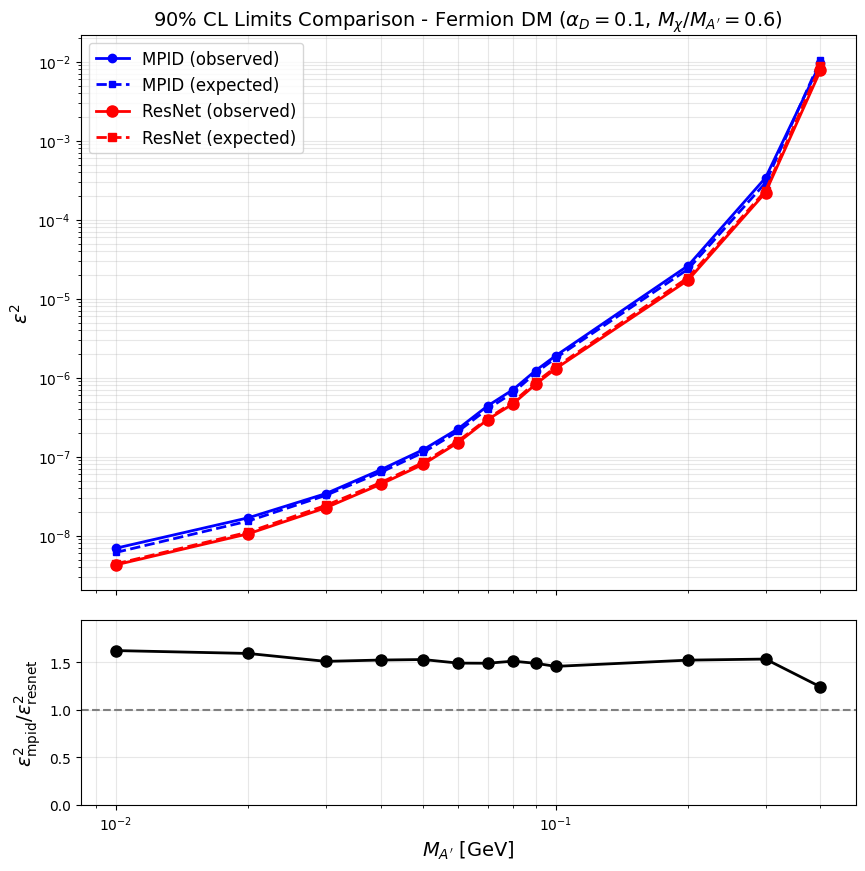

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the MPID sensitivity results
df_mpid = pd.read_csv("/home/hep/an1522/dark_tridents_wspace/outputs/pyhf/sensitivity_results_mpid.csv")
mpid_mass_gev = df_mpid["mass"].values
mpid_observed = df_mpid["epsilon_squared_obs"].values
mpid_expected = df_mpid["epsilon_squared_exp"].values

# Load the ResNet sensitivity results
df_resnet = pd.read_csv("/home/hep/an1522/dark_tridents_wspace/outputs/pyhf/sensitivity_results_resnet.csv")
resnet_mass_gev = df_resnet["mass"].values
resnet_observed = df_resnet["epsilon_squared_obs"].values
resnet_expected = df_resnet["epsilon_squared_exp"].values
ratio = np.array(mpid_observed) / np.array(resnet_observed)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08})

# Limit plots 
ax[0].plot(mpid_mass_gev, mpid_observed, 'b-o', lw=2, markersize=6, label='MPID (observed)')
ax[0].plot(mpid_mass_gev, mpid_expected, 'b--s', lw=2, markersize=5, label='MPID (expected)')
ax[0].plot(resnet_mass_gev, resnet_observed, 'r-o', lw=2, markersize=8, label='ResNet (observed)')
ax[0].plot(resnet_mass_gev, resnet_expected, 'r--s', lw=2, markersize=6, label='ResNet (expected)')

ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_ylabel(r'$\varepsilon^2$', fontsize=14)
ax[0].set_title(r'90% CL Limits Comparison - Fermion DM ($\alpha_D = 0.1$, $M_\chi/M_{A^\prime} = 0.6$)', fontsize=14)
ax[0].legend(fontsize=12)
ax[0].grid(True, alpha=0.3, which='both')
# ax[0].set_xlim(0.008, 0.5)
# ax[0].set_ylim(1e-9, 1e-1)
ax[0].tick_params(axis='x', labelbottom=False)

# Ratio plot
ax[1].plot(resnet_mass_gev, ratio, 'ko-', lw=2, markersize=8)
ax[1].axhline(1.0, color='gray', linestyle='--', linewidth=1.5)
# ax[1].fill_between([0.008, 0.5], 0.9, 1.1, color='green', alpha=0.2, label='±10%')

ax[1].set_xscale('log')
ax[1].set_xlabel(r'$M_{A^\prime}$ [GeV]', fontsize=14)
ax[1].set_ylabel(r'$\varepsilon^2_{\mathrm{mpid}} / \varepsilon^2_{\mathrm{resnet}}$', fontsize=14)
# ax[1].set_xlim(0.008, 0.5)
ax[1].set_ylim(0, max(ratio) * 1.2)
ax[1].grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig("/home/hep/an1522/dark_tridents_wspace/outputs/pyhf/sensitivity_comparison.png", dpi=300, bbox_inches='tight')
print("Plot successfully saved to sensitivity_comparison.png")
plt.show()